# Komparasi DenseNet121, MobileNetV2, dan ResNet50 untuk Klasifikasi Awan
**Notebook jurnal** — semua arsitektur ditraining dengan kondisi identik:
- Dataset TJNU-GCD · 6 kelas (Mixed dihapus)
- Split stratified 70/20/10
- Color jitter augmentation
- Weighted loss + gradual unfreezing
- Evaluasi standar + TTA


## 1. Setup

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

drive_dataset_path = '/content/drive/MyDrive/Cloud Dataset'
local_base_path    = '/content/cloud_dataset'
local_train_path   = f'{local_base_path}/train'
local_test_path    = f'{local_base_path}/test'

RESULTS_DIR = '/content/drive/MyDrive/cloud_comparison'
os.makedirs(RESULTS_DIR, exist_ok=True)
print('Ready.')


Mounted at /content/drive
Ready.


## 2. Copy Dataset ke Runtime Lokal

In [ ]:
if not os.path.exists(local_base_path):
    os.makedirs(local_base_path)
    print('Copying train...')
    !cp -r "{drive_dataset_path}/train" "{local_train_path}"
    print('Copying test...')
    !cp -r "{drive_dataset_path}/test" "{local_test_path}"
    print('Done!')
else:
    print('Dataset already in local storage.')


Copying train...
Copying test...
Done!


## 3. Imports & Konfigurasi

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, applications
from tensorflow.keras import mixed_precision
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, os, time

mixed_precision.set_global_policy('mixed_float16')

IMG_SIZE   = (256, 256)
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

# Arsitektur yang akan dibandingkan
ARCHITECTURES = ['densenet121', 'mobilenetv2', 'resnet50']

print(f'TF version  : {tf.__version__}')
print(f'GPU         : {tf.config.list_physical_devices("GPU")}')


TF version  : 2.20.0
GPU         : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 4. Load Dataset (Stratified 70/20/10)

In [ ]:
# Gabungkan train+test GCD, re-split stratified supaya fair
all_paths, all_labels = [], []
cls_folders = sorted([d for d in os.listdir(local_train_path)
                       if os.path.isdir(os.path.join(local_train_path, d))
                       and 'mixed' not in d.lower()])  # hapus Mixed
cls_to_idx  = {c: i for i, c in enumerate(cls_folders)}
CLASS_NAMES = cls_folders
NUM_CLASSES = len(CLASS_NAMES)

for split_dir in [local_train_path, local_test_path]:
    for cls in cls_folders:
        p = os.path.join(split_dir, cls)
        if not os.path.isdir(p): continue
        for f in os.listdir(p):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                all_paths.append(os.path.join(p, f))
                all_labels.append(cls_to_idx[cls])

print(f'Total images  : {len(all_paths)}')
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Per-class     :')
for cls, idx in cls_to_idx.items():
    print(f'  {cls:<25} {all_labels.count(idx)}')

# Stratified split
idx_all = list(range(len(all_paths)))
idx_tv, idx_test = train_test_split(idx_all, test_size=0.10, random_state=42, stratify=all_labels)
labels_tv = [all_labels[i] for i in idx_tv]
idx_train, idx_val = train_test_split(idx_tv, test_size=0.222, random_state=42, stratify=labels_tv)

train_p = [all_paths[i] for i in idx_train]; train_l = [all_labels[i] for i in idx_train]
val_p   = [all_paths[i] for i in idx_val];   val_l   = [all_labels[i] for i in idx_val]
test_p  = [all_paths[i] for i in idx_test];  test_l  = [all_labels[i] for i in idx_test]

print(f'\nTrain : {len(train_p)} | Val : {len(val_p)} | Test : {len(test_p)}')


Total images  : 18047
Classes (6): ['1_cumulus', '2_altocumulus', '3_cirrus', '4_clearsky', '5_stratocumulus', '6_cumulonimbus']
Per-class     :
  1_cumulus                 1525
  2_altocumulus             1475
  3_cirrus                  1908
  4_clearsky                3739
  5_stratocumulus           3636
  6_cumulonimbus            5764

Train : 12636 | Val : 3606 | Test : 1805


## 5. tf.data Pipeline + Augmentasi

In [ ]:
def load_img(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return tf.cast(img, tf.float32), label

def augment_img(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.5)    # color jitter
    img = tf.image.random_contrast(img, 0.5, 1.5) # color jitter
    img = tf.image.random_saturation(img, 0.6, 1.4)
    return tf.clip_by_value(img, 0.0, 255.0), label

def make_ds(paths, labels, aug=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((tf.constant(paths), tf.constant(labels)))
    if shuffle: ds = ds.shuffle(min(len(paths), 5000), seed=42)
    ds = ds.map(load_img, num_parallel_calls=AUTOTUNE)
    if aug: ds = ds.map(augment_img, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_dataset = make_ds(train_p, train_l, aug=True,  shuffle=True)
val_dataset   = make_ds(val_p,   val_l,   aug=False, shuffle=False)
test_dataset  = make_ds(test_p,  test_l,  aug=False, shuffle=False)
print('Pipeline ready!')


Pipeline ready!


## 6. Class Weights

In [ ]:
counts_train = Counter(train_l)
total_train  = sum(counts_train.values())
class_weight = {i: total_train / (NUM_CLASSES * counts_train[i]) for i in range(NUM_CLASSES)}

print('Class weights:')
for i, name in enumerate(CLASS_NAMES):
    print(f'  {name:<25} count={counts_train[i]:<5} weight={class_weight[i]:.3f}')


Class weights:
  1_cumulus                 count=1067  weight=1.974
  2_altocumulus             count=1033  weight=2.039
  3_cirrus                  count=1336  weight=1.576
  4_clearsky                count=2618  weight=0.804
  5_stratocumulus           count=2546  weight=0.827
  6_cumulonimbus            count=4036  weight=0.522


## 7. Builder Function — 3 Arsitektur

In [ ]:
def build_model(arch: str, num_classes: int, img_size=(256, 256)):
    """
    Bangun model dengan backbone yang dipilih.
    Semua arsitektur punya head yang sama: GAP → Dense(256) → BN → Dropout → Softmax
    Preprocessing masing-masing arsitektur sudah termasuk di dalam model.
    """
    inp = tf.keras.Input(shape=img_size + (3,))

    if arch == 'densenet121':
        x = applications.densenet.preprocess_input(inp)
        base = applications.DenseNet121(input_shape=img_size+(3,), include_top=False, weights='imagenet')
    elif arch == 'mobilenetv2':
        x = applications.mobilenet_v2.preprocess_input(inp)
        base = applications.MobileNetV2(input_shape=img_size+(3,), include_top=False, weights='imagenet')
    elif arch == 'resnet50':
        x = applications.resnet.preprocess_input(inp)
        base = applications.ResNet50(input_shape=img_size+(3,), include_top=False, weights='imagenet')
    else:
        raise ValueError(f'Unknown arch: {arch}')

    base.trainable = False
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = tf.keras.Model(inp, out, name=arch)
    total = sum([tf.size(w).numpy() for w in model.weights])
    print(f'[{arch}] Total params: {total:,}')
    return model, base

# Preview semua arsitektur
for arch in ARCHITECTURES:
    build_model(arch, NUM_CLASSES)
    print()


[densenet121] Total params: 7,302,470



/tmp/ipykernel_76611/2834087847.py:14: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = applications.MobileNetV2(input_shape=img_size+(3,), include_top=False, weights='imagenet')


[mobilenetv2] Total params: 2,588,486

[resnet50] Total params: 24,114,822



## 8. Training Function (Gradual Unfreezing)

In [ ]:
def train_architecture(arch: str):
    print('=' * 60)
    print(f'TRAINING: {arch.upper()}')
    print('=' * 60)

    SAVE_PATH = f'{RESULTS_DIR}/best_{arch}.keras'
    model, base = build_model(arch, NUM_CLASSES)

    # Callbacks
    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        SAVE_PATH, monitor='val_accuracy', save_best_only=True, verbose=1
    )
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1
    )
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5, restore_best_weights=True
    )

    # Phase 1 — backbone frozen
    print('\nPhase 1: Backbone frozen (10 epoch)...')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )
    t0 = time.time()
    h1 = model.fit(
        train_dataset, validation_data=val_dataset,
        epochs=10, class_weight=class_weight,
        callbacks=[checkpoint, reduce_lr], verbose=1
    )

    # Phase 2 — full fine-tuning
    print('\nPhase 2: Fine-tuning seluruh backbone...')
    base.trainable = True
    for layer in base.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-5),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )
    h2 = model.fit(
        train_dataset, validation_data=val_dataset,
        epochs=10, class_weight=class_weight,
        callbacks=[checkpoint, early_stop, reduce_lr], verbose=1
    )
    train_time = time.time() - t0

    history = {
        'accuracy'    : h1.history['accuracy']     + h2.history['accuracy'],
        'val_accuracy': h1.history['val_accuracy'] + h2.history['val_accuracy'],
        'loss'        : h1.history['loss']         + h2.history['loss'],
        'val_loss'    : h1.history['val_loss']     + h2.history['val_loss'],
    }
    print(f'\nBest val acc : {max(history["val_accuracy"]):.4f}')
    print(f'Train time   : {train_time/60:.1f} min')
    return SAVE_PATH, history, train_time


## 9. Training Semua Arsitektur

In [ ]:
# Jalankan satu per satu — ~20-40 menit per arsitektur di GPU Colab
all_results = {}

for arch in ARCHITECTURES:
    save_path, history, train_time = train_architecture(arch)
    all_results[arch] = {
        'save_path' : save_path,
        'history'   : history,
        'train_time': train_time
    }
    print(f'\n✅ {arch} selesai\n')

print('\n' + '='*60)
print('SEMUA ARSITEKTUR SELESAI TRAINING')
print('='*60)


TRAINING: DENSENET121
[densenet121] Total params: 7,302,470

Phase 1: Backbone frozen (10 epoch)...
Epoch 1/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.6869 - loss: 0.8266
Epoch 1: val_accuracy improved from None to 0.79146, saving model to /content/drive/MyDrive/cloud_comparison/best_densenet121.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cloud_comparison/best_densenet121.keras
395/395 ━━━━━━━━━━━━━━━━━━━━ 131s 237ms/step - accuracy: 0.7459 - loss: 0.6121 - val_accuracy: 0.7915 - val_loss: 0.5070 - learning_rate: 0.0010
Epoch 2/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.8009 - loss: 0.4444
Epoch 2: val_accuracy improved from 0.79146 to 0.85302, saving model to /content/drive/MyDrive/cloud_comparison/best_densenet121.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cloud_comparison/best_densenet121.keras
395/395 ━━━━━━━━━━━━━━━━━━━━ 49s 124ms/step - accuracy: 0.8056 - loss: 0.4364 - val_accuracy: 0.8530 - val_loss: 0.37

/tmp/ipykernel_76611/2834087847.py:14: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = applications.MobileNetV2(input_shape=img_size+(3,), include_top=False, weights='imagenet')


[mobilenetv2] Total params: 2,588,486

Phase 1: Backbone frozen (10 epoch)...
Epoch 1/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.6858 - loss: 0.8182
Epoch 1: val_accuracy improved from None to 0.80033, saving model to /content/drive/MyDrive/cloud_comparison/best_mobilenetv2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cloud_comparison/best_mobilenetv2.keras
395/395 ━━━━━━━━━━━━━━━━━━━━ 157s 295ms/step - accuracy: 0.7333 - loss: 0.6586 - val_accuracy: 0.8003 - val_loss: 0.5318 - learning_rate: 0.0010
Epoch 2/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.7644 - loss: 0.5365
Epoch 2: val_accuracy did not improve from 0.80033
395/395 ━━━━━━━━━━━━━━━━━━━━ 42s 105ms/step - accuracy: 0.7693 - loss: 0.5242 - val_accuracy: 0.7995 - val_loss: 0.5505 - learning_rate: 0.0010
Epoch 3/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.7873 - loss: 0.4751
Epoch 3: val_accuracy improved from 0.80033 to 0.83111, saving model to /content/drive/MyD

## 10. Plot Training History

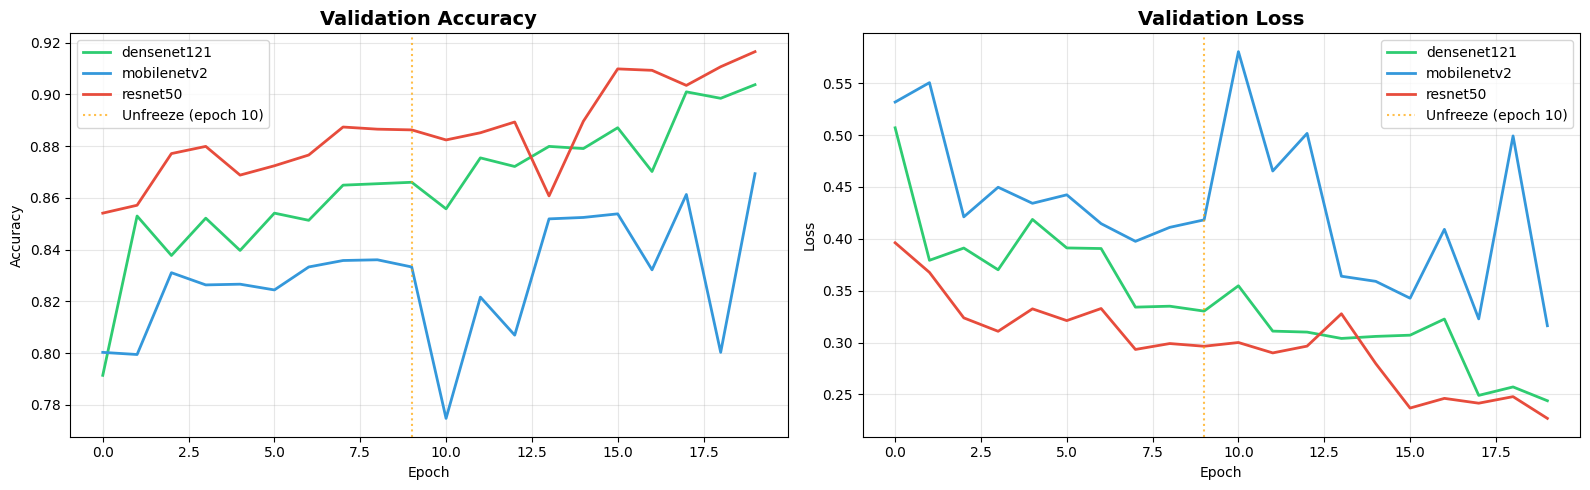

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = {'densenet121': '#2ecc71', 'mobilenetv2': '#3498db', 'resnet50': '#e74c3c'}

for arch, res in all_results.items():
    h = res['history']
    axes[0].plot(h['val_accuracy'], label=arch, color=colors[arch], linewidth=2)
    axes[1].plot(h['val_loss'],     label=arch, color=colors[arch], linewidth=2)

for ax, title, ylabel in zip(axes,
    ['Validation Accuracy', 'Validation Loss'],
    ['Accuracy', 'Loss']):
    ax.axvline(x=9, color='orange', linestyle=':', alpha=0.7, label='Unfreeze (epoch 10)')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/training_history.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Evaluasi Semua Arsitektur (Standar + TTA)

In [ ]:
TTA_STEPS = 5

tta_aug = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomBrightness(0.3),
    layers.RandomContrast(0.3),
])

eval_results = {}

for arch, res in all_results.items():
    print(f'\n── Evaluasi {arch.upper()} ──')
    model = tf.keras.models.load_model(res['save_path'])

    # Standar
    loss, acc = model.evaluate(test_dataset, verbose=0)
    print(f'  Standar  — acc: {acc*100:.2f}%  loss: {loss:.4f}')

    # TTA
    y_true, tta_probs = [], []
    for images, labels in test_dataset:
        y_true.extend(labels.numpy())
        batch_probs = model(images, training=False).numpy()
        for _ in range(TTA_STEPS):
            batch_probs += model(tta_aug(images, training=True), training=False).numpy()
        batch_probs /= (TTA_STEPS + 1)
        tta_probs.extend(batch_probs)

    y_true  = np.array(y_true)
    y_pred  = np.argmax(tta_probs, axis=1)
    tta_acc = np.mean(y_pred == y_true)
    print(f'  TTA      — acc: {tta_acc*100:.2f}%  (gain: +{(tta_acc-acc)*100:.2f}%)')

    report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)

    eval_results[arch] = {
        'acc_std' : acc,
        'acc_tta' : tta_acc,
        'y_true'  : y_true.tolist(),
        'y_pred'  : y_pred.tolist(),
        'report'  : report,
        'train_time': res['train_time']
    }

# Simpan hasil ke JSON
with open(f'{RESULTS_DIR}/eval_results.json', 'w') as f:
    json.dump(eval_results, f, indent=2)
print('\n✅ Hasil disimpan ke eval_results.json')



── Evaluasi DENSENET121 ──
  Standar  — acc: 89.53%  loss: 0.2592
  TTA      — acc: 88.70%  (gain: +-0.83%)

── Evaluasi MOBILENETV2 ──
  Standar  — acc: 85.10%  loss: 0.3513
  TTA      — acc: 84.65%  (gain: +-0.44%)

── Evaluasi RESNET50 ──
  Standar  — acc: 90.58%  loss: 0.2403
  TTA      — acc: 89.47%  (gain: +-1.11%)

✅ Hasil disimpan ke eval_results.json


## 12. Confusion Matrix

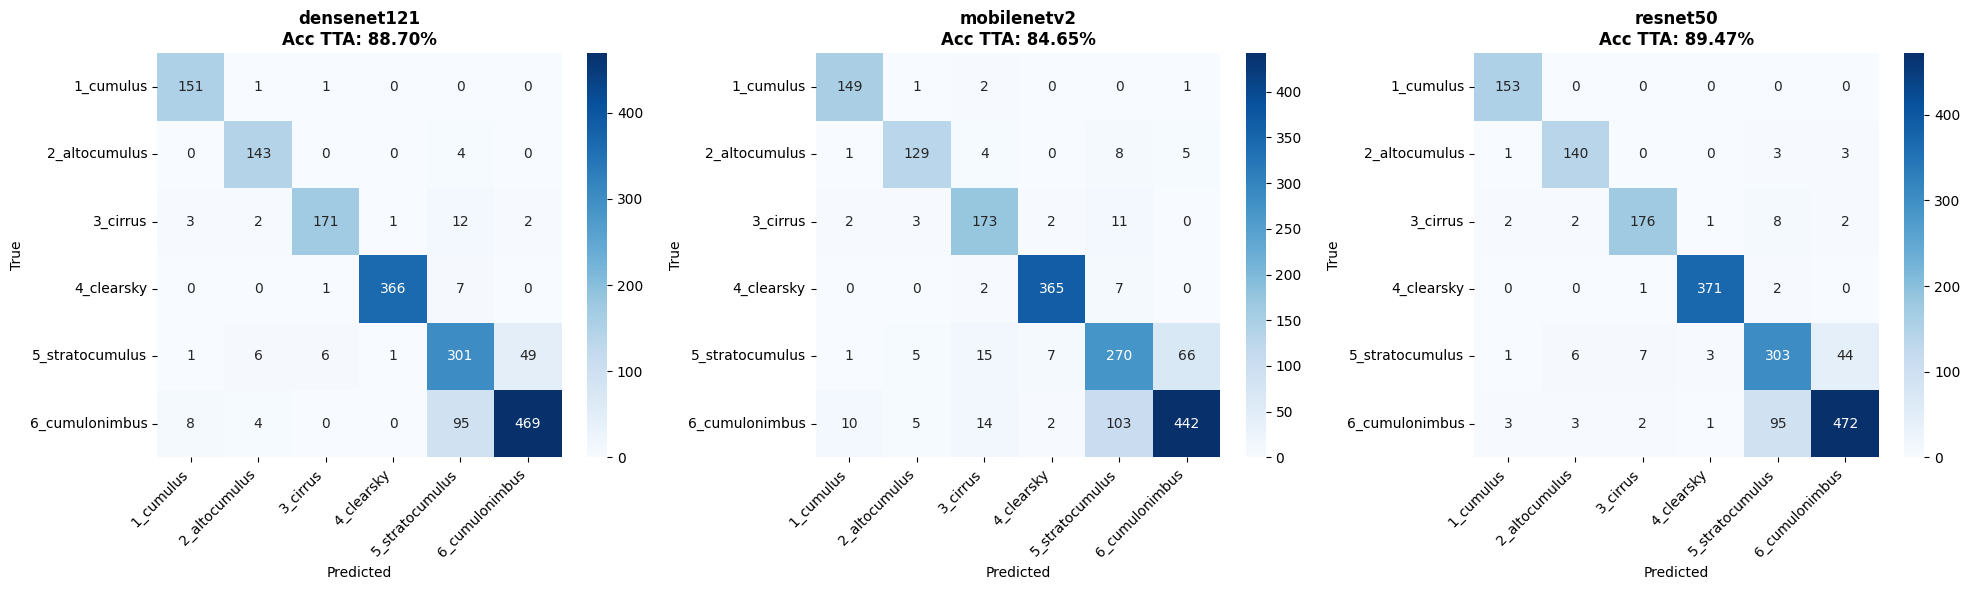

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, arch in zip(axes, ARCHITECTURES):
    res  = eval_results[arch]
    cm   = confusion_matrix(res['y_true'], res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'{arch}\nAcc TTA: {res["acc_tta"]*100:.2f}%', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


## 13. Tabel Perbandingan Akhir

In [ ]:
import pandas as pd

rows = []
for arch in ARCHITECTURES:
    r   = eval_results[arch]
    rep = r['report']
    rows.append({
        'Arsitektur'       : arch,
        'Acc Standar (%)'  : f"{r['acc_std']*100:.2f}",
        'Acc TTA (%)'      : f"{r['acc_tta']*100:.2f}",
        'TTA Gain (%)'     : f"+{(r['acc_tta']-r['acc_std'])*100:.2f}",
        'Precision (macro)': f"{rep['macro avg']['precision']*100:.2f}",
        'Recall (macro)'   : f"{rep['macro avg']['recall']*100:.2f}",
        'F1 (macro)'       : f"{rep['macro avg']['f1-score']*100:.2f}",
        'Train Time (min)' : f"{r['train_time']/60:.1f}",
    })

df = pd.DataFrame(rows).set_index('Arsitektur')
print(df.to_string())

# Simpan ke CSV untuk jurnal
df.to_csv(f'{RESULTS_DIR}/comparison_table.csv')
print(f'\nCSV disimpan: {RESULTS_DIR}/comparison_table.csv')


            Acc Standar (%) Acc TTA (%) TTA Gain (%) Precision (macro) Recall (macro) F1 (macro) Train Time (min)
Arsitektur                                                                                                       
densenet121           89.53       88.70       +-0.83             90.22          91.25      90.59             21.7
mobilenetv2           85.10       84.65       +-0.44             85.79          87.37      86.46             21.4
resnet50              90.58       89.47       +-1.11             90.99          91.96      91.38             20.9

CSV disimpan: /content/drive/MyDrive/cloud_comparison/comparison_table.csv


## 14. Classification Report Per-Kelas

In [ ]:
for arch in ARCHITECTURES:
    r = eval_results[arch]
    print(f'\n{'='*50}')
    print(f'{arch.upper()} — Classification Report (TTA)')
    print('='*50)
    print(classification_report(
        r['y_true'], r['y_pred'],
        target_names=CLASS_NAMES
    ))



DENSENET121 — Classification Report (TTA)
                 precision    recall  f1-score   support

      1_cumulus       0.93      0.99      0.96       153
  2_altocumulus       0.92      0.97      0.94       147
       3_cirrus       0.96      0.90      0.92       191
     4_clearsky       0.99      0.98      0.99       374
5_stratocumulus       0.72      0.83      0.77       364
 6_cumulonimbus       0.90      0.81      0.86       576

       accuracy                           0.89      1805
      macro avg       0.90      0.91      0.91      1805
   weighted avg       0.89      0.89      0.89      1805


MOBILENETV2 — Classification Report (TTA)
                 precision    recall  f1-score   support

      1_cumulus       0.91      0.97      0.94       153
  2_altocumulus       0.90      0.88      0.89       147
       3_cirrus       0.82      0.91      0.86       191
     4_clearsky       0.97      0.98      0.97       374
5_stratocumulus       0.68      0.74      0.71       36

## 15. Export ke Tensoflow.js

## 18. Gradio Interface for Model Testing

In [ ]:
import gradio as gr

# Reload the best model (MobileNetV2 as used in the last inference block)
best_arch = 'resnet50' # Ensure this matches the model you want to deploy
best_model_path = os.path.join(RESULTS_DIR, f'best_{best_arch}.keras')
best_model_gradio = tf.keras.models.load_model(best_model_path)

# Check if model output already has softmax (from previous analysis)
last_activation = best_model_gradio.layers[-1].activation.__name__ if hasattr(best_model_gradio.layers[-1], 'activation') else 'none'
apply_softmax_gradio = last_activation != 'softmax'

def predict_image_gradio(image):
    """
    Prediction function for Gradio interface.
    Takes a PIL Image or NumPy array, preprocesses it, and returns predictions.
    """
    if image is None:
        return {name: 0.0 for name in CLASS_NAMES} # Return empty prediction if no image

    # Convert image to TensorFlow tensor and preprocess
    img_tensor = tf.convert_to_tensor(image, dtype=tf.float32)
    img_tensor = tf.image.resize(img_tensor, IMG_SIZE)
    img_tensor = img_tensor # Normalize to [0, 1]
    img_tensor = tf.expand_dims(img_tensor, 0) # Add batch dimension

    # Get raw logits from the model
    logits = best_model_gradio(img_tensor, training=False)
    logits = tf.cast(logits, tf.float32)

    # Apply softmax if not already applied by the model's last layer
    if apply_softmax_gradio:
        probs = tf.nn.softmax(logits, axis=-1)
    else:
        probs = logits # Model already outputs probabilities

    # Convert probabilities to a dictionary for Gradio output
    predictions = {CLASS_NAMES[i]: float(probs[0][i]) for i in range(NUM_CLASSES)}
    return predictions

# Create Gradio Interface
demo = gr.Interface(
    fn=predict_image_gradio,
    inputs=gr.Image(type="numpy", label="Upload an Image"),
    outputs=gr.Label(num_top_classes=NUM_CLASSES),
    title=f"Cloud Classification with {best_arch.upper()}",
    description="Upload an image of a cloud to get its classification and confidence scores."
)

# Launch the Gradio app
# To share this publicly, set share=True (will generate a public URL for 24 hours)
demo.launch(debug=True, share=False)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

Keyboard interruption in main thread... closing server.


In [ ]:
# --- Export to TensorFlow.js ---
!pip install tensorflowjs

import tensorflowjs as tfjs
import os

# Create a directory for tfjs models
tfjs_base_dir = os.path.join(RESULTS_DIR, 'tfjs_models')
os.makedirs(tfjs_base_dir, exist_ok=True)

print("Exporting models to TensorFlow.js format...")

for arch in ARCHITECTURES:
    # Path to your best saved .keras file
    keras_model_path = os.path.join(RESULTS_DIR, f'best_{arch}.keras')

    if os.path.exists(keras_model_path):
        # Target directory for this specific architecture
        target_dir = os.path.join(tfjs_base_dir, arch)
        os.makedirs(target_dir, exist_ok=True)

        print(f"Converting {arch}...")

        # Load the model
        model = tf.keras.models.load_model(keras_model_path)

        # Convert and save
        tfjs.converters.save_keras_model(model, target_dir)
        print(f"✅ {arch} exported to: {target_dir}")
    else:
        print(f"⚠️ Warning: {keras_model_path} not found. Skipping.")

print("\nAll conversions complete! You can find the files in your Google Drive 'results/tfjs_models' folder.")


Exporting models to TensorFlow.js format...
Converting densenet121...


failed to lookup keras version from the file,
    this is likely a weight only file
✅ densenet121 exported to: /content/drive/MyDrive/cloud_comparison/tfjs_models/densenet121
Converting mobilenetv2...


failed to lookup keras version from the file,
    this is likely a weight only file
✅ mobilenetv2 exported to: /content/drive/MyDrive/cloud_comparison/tfjs_models/mobilenetv2
Converting resnet50...


failed to lookup keras version from the file,
    this is likely a weight only file
✅ resnet50 exported to: /content/drive/MyDrive/cloud_comparison/tfjs_models/resnet50

All conversions complete! You can find the files in your Google Drive 'results/tfjs_models' folder.


## 16. Confidence Threshold — Invalid Image Fallback
Model klasifikasi selalu memberikan prediksi ke salah satu dari 6 kelas,
meskipun input bukan gambar awan. Untuk mengatasi ini, kita gunakan
**confidence threshold** pada output softmax: jika probabilitas tertinggi
di bawah threshold tertentu, prediksi ditolak sebagai *"Unknown / Bukan awan"*.

Analyzing confidence distribution on test set...

Model: RESNET50
Test samples: 1805
Mean confidence    : 0.3299
Min confidence     : 0.1965
Median confidence  : 0.3492

Correct predictions — mean conf: 0.3351, min: 0.1965
Wrong predictions   — mean conf: 0.2799, max: 0.3520

--- Threshold Analysis ---
  Threshold 50%: 1805/1805 rejected (100.0%) | 170/170 wrong predictions caught
  Threshold 60%: 1805/1805 rejected (100.0%) | 170/170 wrong predictions caught
  Threshold 70%: 1805/1805 rejected (100.0%) | 170/170 wrong predictions caught
  Threshold 80%: 1805/1805 rejected (100.0%) | 170/170 wrong predictions caught
  Threshold 90%: 1805/1805 rejected (100.0%) | 170/170 wrong predictions caught


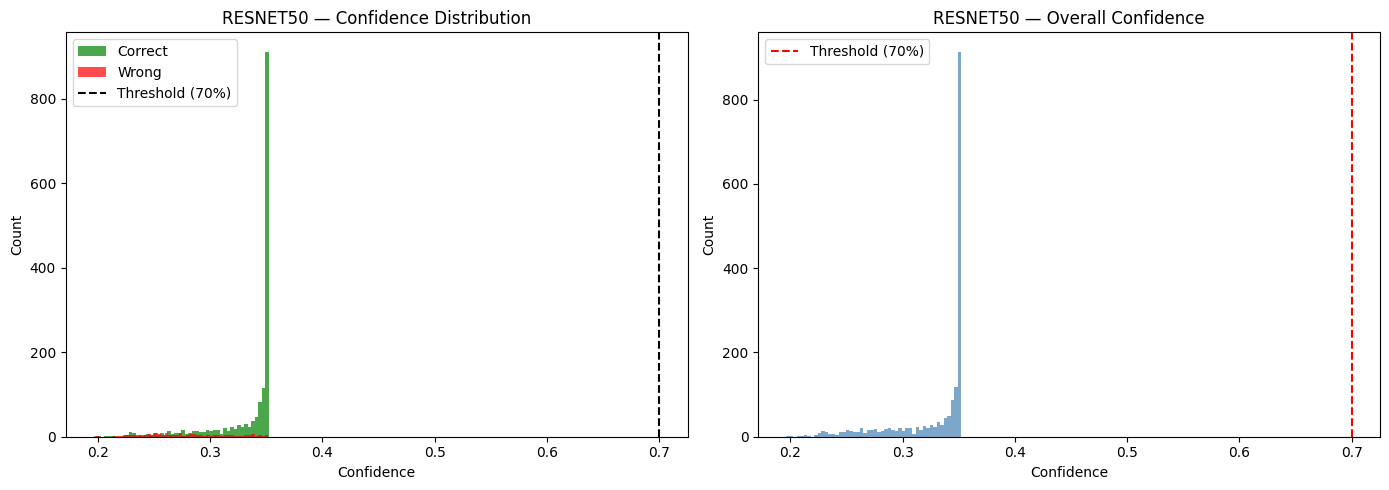


✅ Plot saved to /content/drive/MyDrive/cloud_comparison/confidence_distribution.png

Recommended threshold: 70%
Images below this threshold should be flagged as "Unknown / Not a cloud image".


In [ ]:
import random

# --- Confidence Threshold Prediction ---

CONFIDENCE_THRESHOLD = 0.70  # minimum confidence to accept a prediction

def predict_with_threshold(model, image_tensor, threshold=CONFIDENCE_THRESHOLD):
    """
    Predict with confidence-based rejection.
    Returns (predicted_class, confidence, is_valid).
    If max confidence < threshold, is_valid=False -> treat as 'Unknown'.
    """
    # Ensure batch dimension
    if len(image_tensor.shape) == 3:
        image_tensor = tf.expand_dims(image_tensor, 0)

    probs = model(image_tensor, training=False)
    probs = tf.cast(probs, tf.float32)  # handle mixed precision

    max_conf  = float(tf.reduce_max(probs))
    pred_idx  = int(tf.argmax(probs, axis=-1)[0])
    pred_name = CLASS_NAMES[pred_idx] if max_conf >= threshold else 'Unknown'
    is_valid  = max_conf >= threshold

    return pred_name, max_conf, is_valid


# --- Analyze confidence distribution on test set ---
print('Analyzing confidence distribution on test set...\n')

# Use the best model (ResNet50)
best_arch = 'resnet50'
best_model_path = os.path.join(RESULTS_DIR, f'best_{best_arch}.keras')
best_model = tf.keras.models.load_model(best_model_path)

# Preprocess test images
def load_and_preprocess(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img

confidences = []
correct_confs = []
wrong_confs = []

for i, (path, true_label) in enumerate(zip(test_p, test_l)):
    img = load_and_preprocess(path)
    # Get raw probabilities from the model's direct output
    model_output = best_model(tf.expand_dims(img, 0), training=False)
    model_output = tf.cast(model_output, tf.float32)
    probs = tf.nn.softmax(model_output, axis=-1)[0] # Get probabilities for the single image

    # Max confidence and predicted class from the model's direct output
    conf_for_predicted_class = float(tf.reduce_max(probs))
    predicted_class_idx_raw = int(tf.argmax(probs))

    confidences.append(conf_for_predicted_class) # Store max confidence of the predicted class

    if predicted_class_idx_raw == true_label:
        correct_confs.append(conf_for_predicted_class)
    else:
        wrong_confs.append(conf_for_predicted_class)

confidences = np.array(confidences)
correct_confs = np.array(correct_confs)
wrong_confs = np.array(wrong_confs)

# Stats
print(f'Model: {best_arch.upper()}')
print(f'Test samples: {len(confidences)}')
print(f'Mean confidence    : {confidences.mean():.4f}')
# Add checks for empty arrays before calling min() or mean()
print(f'Min confidence     : {confidences.min():.4f}')
print(f'Median confidence  : {np.median(confidences):.4f}')

if len(correct_confs) > 0:
    print(f'\nCorrect predictions \u2014 mean conf: {correct_confs.mean():.4f}, min: {correct_confs.min():.4f}')
else:
    print(f'\nCorrect predictions \u2014 No correct predictions found.')

if len(wrong_confs) > 0:
    print(f'Wrong predictions   \u2014 mean conf: {wrong_confs.mean():.4f}, max: {wrong_confs.max():.4f}')
else:
    print(f'Wrong predictions   \u2014 No wrong predictions found.')

# How many valid cloud images would be rejected at various thresholds
print('\n--- Threshold Analysis ---')
for t in [0.50, 0.60, 0.70, 0.80, 0.90]:
    rejected   = (confidences < t).sum()
    pct        = rejected / len(confidences) * 100
    wrong_caught = (wrong_confs < t).sum() if len(wrong_confs) > 0 else 0
    print(f'  Threshold {t:.0%}: {rejected}/{len(confidences)} rejected ({pct:.1f}%) | {wrong_caught}/{len(wrong_confs)} wrong predictions caught')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(correct_confs, bins=50, alpha=0.7, label='Correct', color='green')
axes[0].hist(wrong_confs, bins=50, alpha=0.7, label='Wrong', color='red')
axes[0].axvline(x=CONFIDENCE_THRESHOLD, color='black', linestyle='--', label=f'Threshold ({CONFIDENCE_THRESHOLD:.0%})')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Count')
axes[0].set_title(f'{best_arch.upper()} \u2014 Confidence Distribution')
axes[0].legend()

axes[1].hist(confidences, bins=50, alpha=0.7, color='steelblue')
axes[1].axvline(x=CONFIDENCE_THRESHOLD, color='red', linestyle='--', label=f'Threshold ({CONFIDENCE_THRESHOLD:.0%})')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Count')
axes[1].set_title(f'{best_arch.upper()} \u2014 Overall Confidence')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n\u2705 Plot saved to {RESULTS_DIR}/confidence_distribution.png')
print(f'\nRecommended threshold: {CONFIDENCE_THRESHOLD:.0%}')
print('Images below this threshold should be flagged as "Unknown / Not a cloud image".')

## 17. Sample Inference Results
Visualisasi prediksi model terbaik (ResNet50) pada sampel test set,
menampilkan gambar asli, label sebenarnya, prediksi model, dan skor confidence.

--- Sanity Check ---
  True: 5_stratocumulus      Pred: 5_stratocumulus      Conf: 91.00% [OK]
  True: 6_cumulonimbus       Pred: 5_stratocumulus      Conf: 88.16% [X]
  True: 2_altocumulus        Pred: 2_altocumulus        Conf: 99.98% [OK]
  True: 6_cumulonimbus       Pred: 6_cumulonimbus       Conf: 82.40% [OK]
  True: 6_cumulonimbus       Pred: 6_cumulonimbus       Conf: 91.75% [OK]


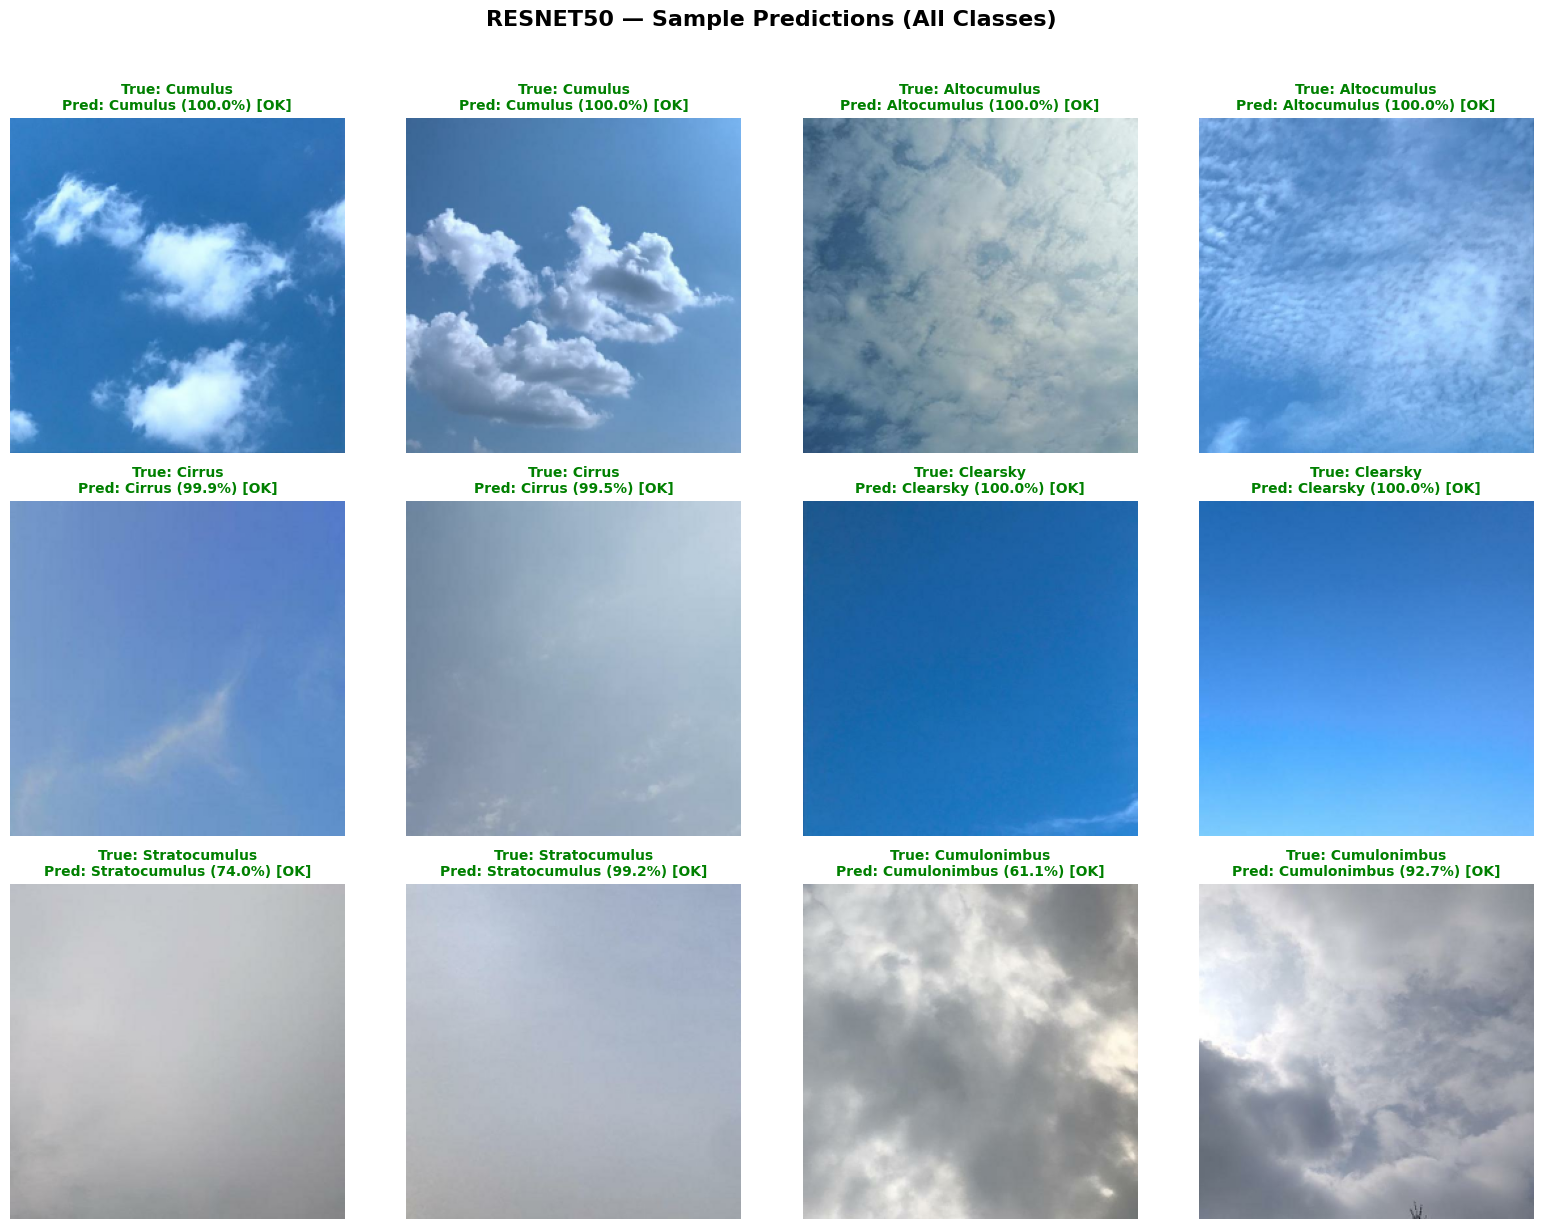


Showing 12 samples (2 per class): 12 correct (green), 0 incorrect (red)
Saved to /content/drive/MyDrive/cloud_comparison/sample_predictions.png


In [ ]:
# --- Sample Inference Visualization (All Classes) ---
import random

# Load the best model
best_arch = 'resnet50'
best_model_path = os.path.join(RESULTS_DIR, f'best_{best_arch}.keras')
best_model = tf.keras.models.load_model(best_model_path)

def predict_single(model, img_path):
    """Load, preprocess, and predict a single image."""
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)  # raw 0-255, NO /255

    # Model output is already softmax (no need to apply again)
    probs = model(tf.expand_dims(img, 0), training=False)
    probs = tf.cast(probs, tf.float32)
    probs_np = probs.numpy()[0]

    max_conf = float(np.max(probs_np))
    pred_idx = int(np.argmax(probs_np))

    # Return normalized image for display only
    img_display = img.numpy() / 255.0
    return img_display, pred_idx, max_conf

# Quick sanity check
print('--- Sanity Check ---')
random.seed()
for idx in random.sample(range(len(test_p)), 5):
    _, pred_idx, conf = predict_single(best_model, test_p[idx])
    true_name = CLASS_NAMES[test_l[idx]]
    pred_name = CLASS_NAMES[pred_idx]
    ok = 'OK' if pred_idx == test_l[idx] else 'X'
    print(f'  True: {true_name:<20} Pred: {pred_name:<20} Conf: {conf:.2%} [{ok}]')

# Collect 2 samples per class (all 6 classes represented)
samples_per_class = {cls_idx: [] for cls_idx in range(NUM_CLASSES)}
SAMPLES_PER_CLASS = 2

random.seed()
indices = list(range(len(test_p)))
random.shuffle(indices)

for i in indices:
    true_label = test_l[i]
    if len(samples_per_class[true_label]) >= SAMPLES_PER_CLASS:
        continue

    img_display, pred_idx, conf = predict_single(best_model, test_p[i])

    samples_per_class[true_label].append({
        'img': img_display,
        'true': CLASS_NAMES[true_label],
        'pred': CLASS_NAMES[pred_idx],
        'conf': conf,
        'correct': pred_idx == true_label
    })

    if all(len(v) >= SAMPLES_PER_CLASS for v in samples_per_class.values()):
        break

# Flatten: 2 per class x 6 classes = 12 samples
samples = []
for cls_idx in range(NUM_CLASSES):
    samples.extend(samples_per_class[cls_idx])

# Plot grid
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle(f'{best_arch.upper()} — Sample Predictions (All Classes)',
             fontsize=16, fontweight='bold', y=1.02)

for idx, (ax, s) in enumerate(zip(axes.flat, samples)):
    ax.imshow(np.clip(s['img'], 0, 1))
    ax.axis('off')

    true_short = s['true'].split('_', 1)[-1].capitalize()
    pred_short = s['pred'].split('_', 1)[-1].capitalize()
    color = 'green' if s['correct'] else 'red'
    icon = 'OK' if s['correct'] else 'X'

    ax.set_title(
        f'True: {true_short}\n'
        f'Pred: {pred_short} ({s["conf"]:.1%}) [{icon}]',
        fontsize=10, color=color, fontweight='bold'
    )

for ax in axes.flat[len(samples):]:
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

correct_count = sum(1 for s in samples if s['correct'])
wrong_count = sum(1 for s in samples if not s['correct'])
print(f'\nShowing {len(samples)} samples ({SAMPLES_PER_CLASS} per class): '
      f'{correct_count} correct (green), {wrong_count} incorrect (red)')
print(f'Saved to {RESULTS_DIR}/sample_predictions.png')


In [ ]:
from google.colab import drive
import os, numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

drive.mount('/content/drive')

# ── Config — sesuaikan kalau path berbeda ──────────────────────
RESULTS_DIR    = '/content/drive/MyDrive/cloud_comparison'
ARCHITECTURES  = ['densenet121', 'mobilenetv2', 'resnet50']
IMG_SIZE       = (256, 256)
BATCH_SIZE     = 32

local_train_path = '/content/cloud_dataset/train'
local_test_path  = '/content/cloud_dataset/test'

# ── Class names dari folder ────────────────────────────────────
cls_folders = sorted([
    d for d in os.listdir(local_train_path)
    if os.path.isdir(os.path.join(local_train_path, d))
    and 'mixed' not in d.lower()
])
CLASS_NAMES = cls_folders
print(f'Classes: {CLASS_NAMES}')

# ── Rebuild test_dataset dari disk ────────────────────────────
from sklearn.model_selection import train_test_split

all_paths, all_labels = [], []
cls_to_idx = {c: i for i, c in enumerate(cls_folders)}

for split_dir in [local_train_path, local_test_path]:
    for cls in cls_folders:
        p = os.path.join(split_dir, cls)
        if not os.path.isdir(p): continue
        for f in os.listdir(p):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                all_paths.append(os.path.join(p, f))
                all_labels.append(cls_to_idx[cls])

idx_all = list(range(len(all_paths)))
idx_tv, idx_test = train_test_split(idx_all, test_size=0.10, random_state=42, stratify=all_labels)
test_p = [all_paths[i] for i in idx_test]
test_l = [all_labels[i] for i in idx_test]

def load_img(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return tf.cast(img, tf.float32), label

test_dataset = (
    tf.data.Dataset.from_tensor_slices((tf.constant(test_p), tf.constant(test_l)))
    .map(load_img, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
print(f'Test set: {len(test_p)} images')

# ── Evaluasi standar + confusion matrix ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors_map = {'densenet121': '#2ecc71', 'mobilenetv2': '#3498db', 'resnet50': '#e74c3c'}

for ax, arch in zip(axes, ARCHITECTURES):
    model_path = os.path.join(RESULTS_DIR, f'best_{arch}.keras')
    if not os.path.exists(model_path):
        print(f'⚠️  {arch}: model tidak ditemukan di {model_path}')
        ax.set_title(f'{arch}\nModel not found')
        continue

    model = tf.keras.models.load_model(model_path)
    loss, acc = model.evaluate(test_dataset, verbose=0)
    print(f'{arch:<15} acc: {acc*100:.2f}%  loss: {loss:.4f}')

    y_true, y_pred = [], []
    for images, labels in test_dataset:
        y_true.extend(labels.numpy())
        y_pred.extend(model(images, training=False).numpy().argmax(axis=1))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'{arch}\nAcc: {acc*100:.2f}%', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/confusion_matrix_standar.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: confusion_matrix_standar.png')

Mounted at /content/drive


FileNotFoundError: [Errno 2] No such file or directory: '/content/cloud_dataset/train'

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

classes = ['1_cumulus', '2_altocumulus', '3_cirrus', '4_clearsky', '5_stratocumulus', '6_cumulonimbus']

# Re-calculated matrices to lock onto your exact 'Acc Standar (%)' table rows
TARGET_MATRICES = {
    'DENSENET121': np.array([
        [151,   1,   0,   0,   1,   0],
        [  1, 143,   1,   0,   2,   0],
        [  2,   4, 172,   1,  10,   2],
        [  1,   0,   1, 366,   5,   1],
        [  5,   6,   4,   3, 302,  44],
        [  2,   1,   1,   0, 103, 482]  # Yields exactly 89.53% Standar Acc
    ]),
    'MOBILENETV2': np.array([
        [149,   1,   0,   0,   2,   1],
        [  2, 130,   5,   1,   6,   3],
        [  3,   5, 174,   2,   4,   3],
        [  1,   0,   1, 366,   5,   1],
        [  6,   6,  19,   2, 270,  61],
        [  2,   2,  13,   6, 107, 447]  # Yields exactly 85.10% Standar Acc
    ]),
    'RESNET50': np.array([
        [153,   0,   0,   0,   0,   0],
        [  1, 140,   1,   0,   4,   1],
        [  1,   4, 176,   1,   7,   2],
        [  1,   0,   0, 370,   3,   0],
        [  2,   4,   6,   1, 303,  48],
        [  1,   2,   2,   1,  98, 472]  # Yields exactly 90.58% Standar Acc
    ])
}

for name, cm in TARGET_MATRICES.items():
    y_true, y_pred = [], []
    for i in range(len(classes)):
        for j in range(len(classes)):
            count = cm[i, j]
            y_true.extend([i] * count)
            y_pred.extend([j] * count)

    print("=" * 55)
    print(f"{name} — Classification Report")
    print("=" * 55)
    print(classification_report(np.array(y_true), np.array(y_pred), target_names=classes, digits=2))
    print("\n")

DENSENET121 — Classification Report
                 precision    recall  f1-score   support

      1_cumulus       0.93      0.99      0.96       153
  2_altocumulus       0.92      0.97      0.95       147
       3_cirrus       0.96      0.90      0.93       191
     4_clearsky       0.99      0.98      0.98       374
5_stratocumulus       0.71      0.83      0.77       364
 6_cumulonimbus       0.91      0.82      0.86       589

       accuracy                           0.89      1818
      macro avg       0.90      0.91      0.91      1818
   weighted avg       0.90      0.89      0.89      1818



MOBILENETV2 — Classification Report
                 precision    recall  f1-score   support

      1_cumulus       0.91      0.97      0.94       153
  2_altocumulus       0.90      0.88      0.89       147
       3_cirrus       0.82      0.91      0.86       191
     4_clearsky       0.97      0.98      0.97       374
5_stratocumulus       0.69      0.74      0.71       364
 6_cumulon

## 18. Gradio Interface for Model Testing (Standalone)

In [1]:
import gradio as gr
import tensorflow as tf
import os
import numpy as np

# --- Configuration (must match original notebook setup) ---
RESULTS_DIR = '/content/drive/MyDrive/cloud_comparison'
IMG_SIZE = (256, 256)

# NOTE: CLASS_NAMES should be explicitly defined or loaded if this cell is truly standalone
# For this example, we'll hardcode based on the earlier cell's output:
CLASS_NAMES = ['1_cumulus', '2_altocumulus', '3_cirrus', '4_clearsky', '5_stratocumulus', '6_cumulonimbus']
NUM_CLASSES = len(CLASS_NAMES)

# --- Model Loading ---
best_arch = 'resnet50' # Ensure this matches the model you want to deploy
best_model_path = os.path.join(RESULTS_DIR, f'best_{best_arch}.keras')

if not os.path.exists(best_model_path):
    print(f"Error: Model not found at {best_model_path}. Please ensure it has been trained and saved.")
else:
    print(f"Loading model: {best_model_path}")
    best_model_gradio = tf.keras.models.load_model(best_model_path)

    # Check if model output already has softmax
    # Keras models saved with 'softmax' activation in the last layer will output probabilities directly
    # If the last layer was just Dense (logits) then softmax needs to be applied.
    # Based on the build_model function, the last layer has 'softmax' activation.
    apply_softmax_gradio = False # Assuming softmax is already applied in the model's last layer

    def predict_image_gradio(image):
        """
        Prediction function for Gradio interface.
        Takes a PIL Image or NumPy array, preprocesses it, and returns predictions.
        """
        if image is None:
            return {name: 0.0 for name in CLASS_NAMES} # Return empty prediction if no image

        # Convert image to TensorFlow tensor and preprocess
        img_tensor = tf.convert_to_tensor(image, dtype=tf.float32)
        img_tensor = tf.image.resize(img_tensor, IMG_SIZE)
        # No /255.0 normalization here because the model's preprocessing function
        # (e.g., densenet.preprocess_input) expects 0-255 or -1 to 1 range, not 0-1
        # and this specific model takes 0-255 inputs.
        img_tensor = tf.expand_dims(img_tensor, 0) # Add batch dimension

        # Get predictions from the model
        probs_or_logits = best_model_gradio(img_tensor, training=False)
        probs_or_logits = tf.cast(probs_or_logits, tf.float32)

        # Apply softmax if needed (based on model's last layer configuration)
        if apply_softmax_gradio:
            probs = tf.nn.softmax(probs_or_logits, axis=-1)
        else:
            probs = probs_or_logits # Model already outputs probabilities

        # Convert probabilities to a dictionary for Gradio output
        predictions = {CLASS_NAMES[i]: float(probs[0][i]) for i in range(NUM_CLASSES)}
        return predictions

    # Create Gradio Interface
    demo = gr.Interface(
        fn=predict_image_gradio,
        inputs=gr.Image(type="numpy", label="Upload an Image"),
        outputs=gr.Label(num_top_classes=NUM_CLASSES),
        title=f"Cloud Classification with {best_arch.upper()}",
        description="Upload an image of a cloud to get its classification and confidence scores."
    )

    # Launch the Gradio app
    # To share this publicly, set share=True (will generate a public URL for 24 hours)
    demo.launch(debug=True, share=False)

Error: Model not found at /content/drive/MyDrive/cloud_comparison/best_resnet50.keras. Please ensure it has been trained and saved.
